## Project goal

The final objective of this project is to design a battery dispatch / MPC system
that can operate under uncertainty in renewable generation and load.

To reach this goal the project is divided into phases:

Phase 1 — Build data  
Phase 2 — Understand data  
Phase 3 — Model system  
Phase 4 — MPC

This notebook corresponds to Phase 2.

# Phase 2 — Understanding Forecast Errors and Uncertainty

Goal of this phase:

After building the full dataset in Phase 1, the next step is to understand how reliable the data is.

Forecasts are never perfect.  
Actual generation and load always differ from predicted values.

Before building any control algorithm, we must understand:

- how large the errors are
- when they happen
- which variables are most uncertain
- how uncertainty changes during the day

This phase builds the statistical model of forecast error that will later be used
inside the battery control and MPC algorithm.

## Available data after Phase 1

After Phase 1 the dataset contains, for each hour:

Forecasts:
- load forecast
- solar forecast
- wind onshore forecast
- wind offshore forecast

Actual values:
- load actual
- solar actual
- wind onshore actual
- wind offshore actual

All timestamps are aligned to hourly resolution.

The data covers multiple years (2015–2025) for Germany.

## Why actual data is required

Forecasts alone are not enough.

To measure uncertainty we need to compare:

actual − forecast

This difference is called forecast error.

Without error statistics we cannot design
a robust control algorithm.

## Error definition

For each variable:

error = actual − forecast

This definition was applied during the data pipeline stage when the merged
hourly dataset was created.

The merged files therefore already contain the following error columns:

- load_error
- solar_error
- wind_onshore_error
- wind_offshore_error

With this definition:

- Positive error means the real value was higher than forecast.
- Negative error means the real value was lower than forecast.

This convention is useful for later control design.

Example:

If solar_error < 0  
- the forecast expected more solar than actually produced  
- the system may need additional generation or battery discharge.

If load_error > 0  
- real demand was higher than expected  
- the system must supply more power than planned.

In Phase 2, these error values are analyzed statistically in order to
understand the uncertainty that the controller must handle.

## Why we need statistics of errors

Errors are not constant.

They change with:
- hour of day
- season
- weather conditions
- renewable level

Using a single error value would be unrealistic.

Instead we compute statistics:
- mean error
- standard deviation
- percentiles

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# go to project root automatically
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(ROOT, "data", "processed")

print("DATA_DIR =", DATA_DIR)

global_stats = pd.read_csv(os.path.join(DATA_DIR, "error_stats_global.csv"))
hourly_stats = pd.read_csv(os.path.join(DATA_DIR, "error_stats_hourly.csv"))
profile = pd.read_csv(os.path.join(DATA_DIR, "uncertainty_profile_hourly.csv"))

global_stats.head()

DATA_DIR = /Users/linearityproductions/Desktop/grid_mpc_project/data/processed


,year,variable,n,mean_error,std_error,mae,rmse,min_error,max_error,p50,p75,p90,p95,p99
0,2015,solar,8759,104.297910,833.072443,394.013445,839.528746,-5863.2425,6465.9225,-0.1425,103.01250,850.2180,1593.01825,3173.09720
1,2015,wind_onshore,8759,-217.145117,1381.749044,1003.395266,1398.629490,-11835.6950,5527.0600,-114.4325,498.63375,1266.5765,1947.73000,3584.69075
2,2015,wind_offshore,8735,-239.266840,451.800386,372.432709,511.222888,-1893.8725,1391.1250,-179.8475,11.52125,255.2145,436.77800,780.90020
3,2015,load,8759,-3039.474020,2423.157822,3263.671951,3887.084485,-14714.4150,9949.7875,-2989.8775,-1580.41750,-202.2465,676.94425,2672.94785
4,2016,solar,8783,19.745967,701.371502,337.071578,701.609492,-5329.7100,4554.4325,-0.1375,67.23750,610.8895,1111.65800,2356.07860


## Global error statistics

First we compute statistics over the whole year.

This gives an overall idea of:

- bias (mean error)
- spread (std)
- extreme values (p95, p99)

However, global statistics hide time structure.

### Global uncertainty scale

Different variables have very different forecast uncertainty.

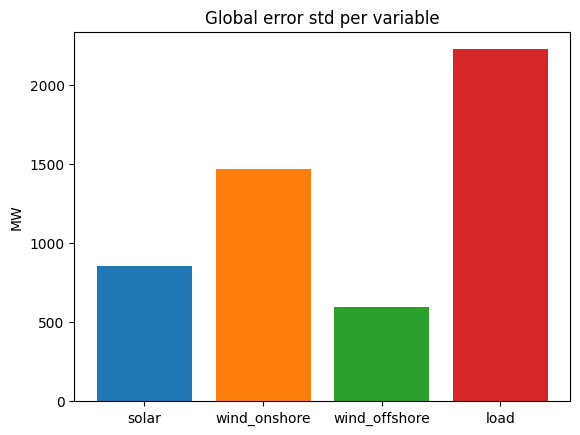

In [32]:
df = global_stats.copy()

plt.figure()
for var in df["variable"].unique():
    v = df[df["variable"] == var]
    plt.bar(var, v["std_error"].mean())

plt.title("Global error std per variable")
plt.ylabel("MW")
plt.show()

## Hourly error statistics

Errors depend strongly on hour of day.

Examples:

Solar
- zero uncertainty at night
- large uncertainty during daylight

Load
- different behavior morning vs night

Wind
- large variability all day

Therefore statistics were computed for each hour separately.

### Solar uncertainty

Solar uncertainty is near zero at night and large during daylight.

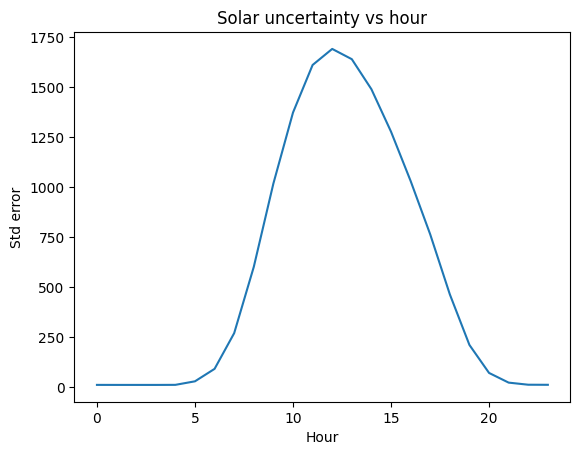

In [33]:
df = profile.copy()
solar = df[df["variable"] == "solar"]

plt.figure()
plt.plot(solar["hour"], solar["std_error"])
plt.title("Solar uncertainty vs hour")
plt.xlabel("Hour")
plt.ylabel("Std error")
plt.show()

## Observations from hourly statistics

Load
- persistent bias across day
- large uncertainty during morning/daytime

Solar
- very low error at night
- high uncertainty during daylight

Wind onshore
- largest uncertainty
- heavy tails

Wind offshore
- smoother, smaller spread

Conclusion:
uncertainty must depend on hour.

## Building the uncertainty profile

From hourly statistics we build:

uncertainty_profile_hourly.csv

For each variable and hour:

- mean_error
- std_error
- percentiles

This file will be used by the battery model.

## Simplified uncertainty model

For the first battery model we use:

mean_error
std_error

This is simple but sufficient.

Later phases may use:
- p95
- p99
- asymmetric bounds
- scenario sampling

## Key insights from Phase 2

- Load forecast error is biased and should not be treated as zero-mean.
- Load uncertainty changes with hour and is stronger during active daytime periods.
- Solar uncertainty is highly time-dependent and is essentially negligible at night.
- Wind onshore is the most difficult renewable variable and has the largest tails.
- Wind offshore is more stable than wind onshore, so keeping them separate was the correct decision.
- A single global uncertainty value per variable would lose too much structure.
- The first control-ready uncertainty object should therefore be hour-dependent.

## Short conclusion

Phase 2 shows that forecast errors are structured rather than random.

Different variables behave differently, and uncertainty depends strongly on hour of day.
Because of this, later control design should not assume constant or zero-mean uncertainty.

The main result of this phase is the construction of an hourly uncertainty profile,
which will be used in Phase 3 to build a battery model under uncertainty.

## Transition to Phase 3

Phase 2 produced:

uncertainty_profile_hourly.csv

This file summarizes the uncertainty seen by the controller
and will be used as input to the first battery model.

Next phase:

Phase 3 — Model system